In [11]:
!pip install langchain langchain-openai langchain-anthropic langchain-community langgraph python-dotenv

In [12]:
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
import operator


print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [ ]:
OPENROUTER_API_KEY="*************************************************************8"

In [ ]:
from langchain_openai import ChatOpenAI


def get_model(temperature: float = 0.0):
    """
    Returns the Trinity-Large-Preview model via OpenRouter.
    """
    return ChatOpenAI(
        model="arcee-ai/trinity-large-preview:free",
        openai_api_key=OPENROUTER_API_KEY,
        openai_api_base="https://openrouter.ai/api/v1",
        temperature=temperature,
        default_headers={
            "HTTP-Referer": "http://localhost:3000",
            "X-Title": "Coffee Shop Chatbot"
        }
    )

llm = get_model()

In [15]:
class ChatState(TypedDict):
    """State for our chatbot containing message history."""
    messages: Annotated[Sequence[BaseMessage], operator.add]

print("✓ State defined")

✓ State defined


In [16]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful AI assistant. Be conversational, friendly, and concise."),
    MessagesPlaceholder(variable_name="messages"),
])

print("✓ Prompt template created")

✓ Prompt template created


In [17]:
def chatbot(state: ChatState) -> ChatState:
    """
    Process the current state and generate a response.
    
    Args:
        state: Current conversation state with message history
        
    Returns:
        Updated state with AI response added to messages
    """

    messages = state["messages"]
    

    formatted_prompt = prompt.invoke({"messages": messages})
    

    response = llm.invoke(formatted_prompt)
    
    return {"messages": [response]}

print("✓ Chatbot function defined")

✓ Chatbot function defined


In [18]:

workflow = StateGraph(ChatState)


workflow.add_node("chatbot", chatbot)


workflow.set_entry_point("chatbot")


workflow.add_edge("chatbot", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print("✓ LangGraph compiled successfully!")

✓ LangGraph compiled successfully!


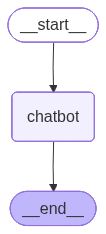

In [19]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization not available: {e}")
    print("Install graphviz to see the graph: pip install graphviz")

In [27]:
def chat_loop():
    """Interactive chat loop."""
    print("=" * 60)
    print("INTERACTIVE CHATBOT")
    print("=" * 60)
    print("Commands:")
    print("  - Type 'quit' or 'exit' to end")
    print("  - Type 'history' to see conversation history")
    print("  - Type 'new' to start a new conversation")
    print("=" * 60 + "\n")
    

    thread_id = "interactive-session"
    config = {"configurable": {"thread_id": thread_id}}
    
    while True:
        # Get user input
        user_input = input("You: ").strip()
        
        if not user_input:
            continue

        print(f"\nUser: {user_input}\n")
        

        if user_input.lower() in ['quit', 'exit']:
            print("\nGoodbye! 👋")
            break
        
        if user_input.lower() == 'history':
            current_state = app.get_state(config)
            print("\n--- Conversation History ---")
            for msg in current_state.values['messages']:
                role = "You" if isinstance(msg, HumanMessage) else "Bot"
                print(f"{role}: {msg.content}")
            print("--- End of History ---\n")
            continue
        
        if user_input.lower() == 'new':
            thread_id = f"session-{hash(str(os.urandom(16)))}"[:10]
            config = {"configurable": {"thread_id": thread_id}}
            print("✓ Started new conversation\n")
            continue
        

        try:
            response = app.invoke(
                {"messages": [HumanMessage(content=user_input)]},
                config=config
            )
            print(f"\nBot: {response['messages'][-1].content}\n")
        except Exception as e:
            print(f"\nError: {e}")
            print("Please check your API key and connection.\n")


chat_loop()

INTERACTIVE CHATBOT
Commands:
  - Type 'quit' or 'exit' to end
  - Type 'history' to see conversation history
  - Type 'new' to start a new conversation


User: what is machine learning


Bot: Machine learning is a subfield of artificial intelligence that focuses on developing algorithms and statistical models that enable computer systems to learn and improve their performance on a specific task without being explicitly programmed.

The key idea behind machine learning is that systems can learn from data, identify patterns, and make decisions with minimal human intervention. Instead of writing code with specific instructions, machine learning algorithms use computational methods to "learn" information directly from data.

There are several types of machine learning:

1. Supervised learning: The algorithm learns from labeled training data, making predictions or decisions based on input-output pairs.

2. Unsupervised learning: The algorithm identifies patterns and structures in unlabeled